# ECDT — RCAEval Dataset Exploration

**Objectif :** première exploration des 735 failure cases de RCAEval à partir de `cases.parquet`.

Ce notebook constitue l'étape initiale de **DATA-01 — Exploitation du dataset** du projet ECDT.

Il ne modifie pas les données brutes. Il permet de :
- charger l'index des 735 cas ;
- inspecter sa structure ;
- vérifier les systèmes, suites et types de faults ;
- explorer les root causes et timestamps ;
- identifier les candidats pour les trois scénarios ECDT :
  - CPU saturation
  - Database latency
  - Network failure

> Les mappings vers les scénarios ECDT ne sont pas considérés comme validés dans ce notebook : ils devront être confirmés après inspection de la télémétrie réelle.

## 0. Préparation

Le notebook peut fonctionner avec :
- un `cases.parquet` téléchargé localement ;
- ou directement avec le dataset Hugging Face si `huggingface_hub` est installé.

Structure recommandée :

```text
ecdt-project/
├── data/
│   └── raw/
│       └── RCAEval/
│           └── cases.parquet
└── notebooks/
    └── 01_dataset_exploration.ipynb
```

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CASES_PATH = PROJECT_ROOT / "data" / "raw" / "RCAEval" / "cases.parquet"

print("Project root:", PROJECT_ROOT)
print("cases.parquet:", CASES_PATH)
print("Exists:", CASES_PATH.exists())

Project root: C:\Users\ou2_s\Documents\GitHub\ECDT
cases.parquet: C:\Users\ou2_s\Documents\GitHub\ECDT\data\raw\RCAEval\cases.parquet
Exists: True


## 1. Charger `cases.parquet`

RCAEval indique que `cases.parquet` indexe les 735 cas et contient notamment le dataset, le cas, la root cause service, le fault, le timestamp d'injection et la taille des métriques.

In [2]:
if not CASES_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {CASES_PATH}\n"
        "Téléchargez d'abord cases.parquet dans data/raw/RCAEval/."
    )

cases = pd.read_parquet(CASES_PATH)

print(f"Nombre de lignes : {len(cases):,}")
print(f"Nombre de colonnes : {len(cases.columns)}")
print("\nColonnes :")
print(list(cases.columns))

Nombre de lignes : 735
Nombre de colonnes : 22

Colonnes :
['case', 'dataset', 'suite', 'system', 'system_name', 'root_cause_service', 'fault', 'fault_description', 'repetition', 'inject_time', 'n_metrics', 'n_timesteps', 'time_start', 'time_end', 'duration_minutes', 'normal_timesteps', 'faulty_timesteps', 'has_logs', 'n_logs', 'has_traces', 'n_traces', 'has_root_cause_file']


In [3]:
display(cases.head())
display(cases.info())

,case,dataset,suite,system,system_name,root_cause_service,fault,fault_description,repetition,inject_time,...,time_start,time_end,duration_minutes,normal_timesteps,faulty_timesteps,has_logs,n_logs,has_traces,n_traces,has_root_cause_file
0,re1ob_adservice_cpu_1,RE1-OB,RE1,ob,Online Boutique,adservice,cpu,CPU stress,1,1685202688,...,1685200588,1685204788,70.0,2100,2101,False,0,False,0,False
1,re1ob_adservice_cpu_2,RE1-OB,RE1,ob,Online Boutique,adservice,cpu,CPU stress,2,1685206967,...,1685204867,1685209067,70.0,2100,2101,False,0,False,0,False
2,re1ob_adservice_cpu_3,RE1-OB,RE1,ob,Online Boutique,adservice,cpu,CPU stress,3,1685211245,...,1685209145,1685213345,70.0,2100,2101,False,0,False,0,False
3,re1ob_adservice_cpu_4,RE1-OB,RE1,ob,Online Boutique,adservice,cpu,CPU stress,4,1685229704,...,1685227604,1685231804,70.0,2100,2101,False,0,False,0,False
4,re1ob_adservice_cpu_5,RE1-OB,RE1,ob,Online Boutique,adservice,cpu,CPU stress,5,1685220134,...,1685218034,1685222234,70.0,2100,2101,False,0,False,0,False


<class 'pandas.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   case                 735 non-null    str    
 1   dataset              735 non-null    str    
 2   suite                735 non-null    str    
 3   system               735 non-null    str    
 4   system_name          735 non-null    str    
 5   root_cause_service   735 non-null    str    
 6   fault                735 non-null    str    
 7   fault_description    735 non-null    str    
 8   repetition           735 non-null    int64  
 9   inject_time          735 non-null    int64  
 10  n_metrics            735 non-null    int64  
 11  n_timesteps          735 non-null    int64  
 12  time_start           735 non-null    int64  
 13  time_end             735 non-null    int64  
 14  duration_minutes     735 non-null    float64
 15  normal_timesteps     735 non-null    int64  
 16  f

None

## 2. Contrôles de base

In [4]:
print("Nombre de cas :", len(cases))
print("Doublons :", cases.duplicated().sum())
print("\nValeurs nulles par colonne :")
display(cases.isna().sum().sort_values(ascending=False).to_frame("missing"))

Nombre de cas : 735
Doublons : 0

Valeurs nulles par colonne :


,missing
case,0
dataset,0
suite,0
system,0
system_name,0
root_cause_service,0
fault,0
fault_description,0
repetition,0
inject_time,0


## 3. Datasets / benchmark suites

In [5]:
if "dataset" in cases.columns:
    dataset_counts = cases["dataset"].value_counts().sort_index()
    display(dataset_counts.to_frame("cases"))
else:
    print("Colonne 'dataset' absente.")

,cases
dataset,
RE1-OB,125
RE1-SS,125
RE1-TT,125
RE2-OB,90
RE2-SS,90
RE2-TT,90
RE3-OB,30
RE3-SS,30
RE3-TT,30


## 4. Types de faults

In [6]:
if "fault" in cases.columns:
    fault_counts = cases["fault"].value_counts()
    display(fault_counts.to_frame("cases"))
else:
    print("Colonne 'fault' absente.")

,cases
fault,
cpu,120
delay,120
disk,120
loss,120
mem,120
socket,45
f3,26
f1,26
f4,19


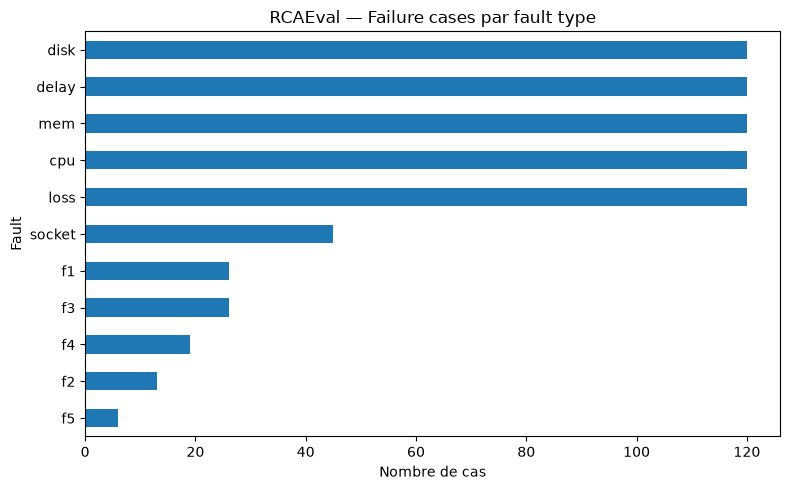

In [7]:
if "fault" in cases.columns:
    ax = cases["fault"].value_counts().sort_values(ascending=True).plot(
        kind="barh",
        figsize=(8, 5),
        title="RCAEval — Failure cases par fault type"
    )
    ax.set_xlabel("Nombre de cas")
    ax.set_ylabel("Fault")
    plt.tight_layout()
    plt.show()

## 5. Systèmes microservices

In [8]:
# Le système peut être déduit du nom du dataset (RE2-OB, RE2-SS, RE2-TT, etc.)
# lorsque la colonne 'dataset' est disponible.
if "dataset" in cases.columns:
    systems = (
        cases["dataset"]
        .astype(str)
        .str.extract(r"-(OB|SS|TT)$", expand=False)
        .map({"OB": "Online Boutique", "SS": "Sock Shop", "TT": "Train Ticket"})
    )
    display(systems.value_counts(dropna=False).to_frame("cases"))

,cases
dataset,
Online Boutique,245
Sock Shop,245
Train Ticket,245


## 6. Root cause services

In [9]:
if "root_cause_service" in cases.columns:
    display(
        cases["root_cause_service"]
        .value_counts()
        .head(30)
        .to_frame("cases")
    )
else:
    print("Colonne 'root_cause_service' absente.")

,cases
root_cause_service,
ts-auth-service,58
ts-route-service,58
carts,55
orders,52
currencyservice,46
checkoutservice,43
productcatalogservice,43
catalogue,43
payment,43


## 7. Timestamps d'injection

`inject_time` correspond au timestamp d'injection de la faute dans les cas RCAEval. Nous le convertissons en datetime pour permettre les analyses temporelles ultérieures.

In [10]:
if "inject_time" in cases.columns:
    cases["inject_time_dt"] = pd.to_datetime(cases["inject_time"], unit="s", errors="coerce")
    print("Timestamp min :", cases["inject_time_dt"].min())
    print("Timestamp max :", cases["inject_time_dt"].max())
    display(cases[["inject_time", "inject_time_dt"]].head())
else:
    print("Colonne 'inject_time' absente.")

Timestamp min : 1970-07-15 23:39:02
Timestamp max : 2024-12-10 13:14:06


,inject_time,inject_time_dt
0,1685202688,2023-05-27 15:51:28
1,1685206967,2023-05-27 17:02:47
2,1685211245,2023-05-27 18:14:05
3,1685229704,2023-05-27 23:21:44
4,1685220134,2023-05-27 20:42:14


## 8. Identifier les candidats pour les scénarios ECDT

In [11]:
# IMPORTANT :
# Ceci est une présélection par fault type uniquement.
# Elle ne valide PAS encore que chaque cas représente le scénario ECDT correspondant.

candidate_faults = {
    "cpu_saturation": {"cpu"},
    "database_latency": {"delay"},
    "network_failure": {"loss", "socket"},
}

if "fault" in cases.columns:
    for scenario, fault_types in candidate_faults.items():
        subset = cases[cases["fault"].isin(fault_types)].copy()
        print(f"\n{scenario}")
        print(f"  Fault types considérés : {sorted(fault_types)}")
        print(f"  Nombre de candidats : {len(subset)}")
        display(
            subset[
                [c for c in [
                    "case", "dataset", "fault",
                    "root_cause_service", "inject_time"
                ] if c in subset.columns]
            ].head(20)
        )


cpu_saturation
  Fault types considérés : ['cpu']
  Nombre de candidats : 120


,case,dataset,fault,root_cause_service,inject_time
0,re1ob_adservice_cpu_1,RE1-OB,cpu,adservice,1685202688
1,re1ob_adservice_cpu_2,RE1-OB,cpu,adservice,1685206967
2,re1ob_adservice_cpu_3,RE1-OB,cpu,adservice,1685211245
3,re1ob_adservice_cpu_4,RE1-OB,cpu,adservice,1685229704
4,re1ob_adservice_cpu_5,RE1-OB,cpu,adservice,1685220134
25,re1ob_cartservice_cpu_1,RE1-OB,cpu,cartservice,1685251430
26,re1ob_cartservice_cpu_2,RE1-OB,cpu,cartservice,1685255770
27,re1ob_cartservice_cpu_3,RE1-OB,cpu,cartservice,1685260110
28,re1ob_cartservice_cpu_4,RE1-OB,cpu,cartservice,1685264450
29,re1ob_cartservice_cpu_5,RE1-OB,cpu,cartservice,1685268791



database_latency
  Fault types considérés : ['delay']
  Nombre de candidats : 120


,case,dataset,fault,root_cause_service,inject_time
5,re1ob_adservice_delay_1,RE1-OB,delay,adservice,1692583932
6,re1ob_adservice_delay_2,RE1-OB,delay,adservice,1692584700
7,re1ob_adservice_delay_3,RE1-OB,delay,adservice,1692585468
8,re1ob_adservice_delay_4,RE1-OB,delay,adservice,1692586236
9,re1ob_adservice_delay_5,RE1-OB,delay,adservice,1692612189
30,re1ob_cartservice_delay_1,RE1-OB,delay,cartservice,1692628112
31,re1ob_cartservice_delay_2,RE1-OB,delay,cartservice,1692628881
32,re1ob_cartservice_delay_3,RE1-OB,delay,cartservice,1692608348
33,re1ob_cartservice_delay_4,RE1-OB,delay,cartservice,1692621704
34,re1ob_cartservice_delay_5,RE1-OB,delay,cartservice,1692629647



network_failure
  Fault types considérés : ['loss', 'socket']
  Nombre de candidats : 165


,case,dataset,fault,root_cause_service,inject_time
15,re1ob_adservice_loss_1,RE1-OB,loss,adservice,1693322053
16,re1ob_adservice_loss_2,RE1-OB,loss,adservice,1693316537
17,re1ob_adservice_loss_3,RE1-OB,loss,adservice,1693317308
18,re1ob_adservice_loss_4,RE1-OB,loss,adservice,1692660354
19,re1ob_adservice_loss_5,RE1-OB,loss,adservice,1693318081
40,re1ob_cartservice_loss_1,RE1-OB,loss,cartservice,1693313452
41,re1ob_cartservice_loss_2,RE1-OB,loss,cartservice,1692641016
42,re1ob_cartservice_loss_3,RE1-OB,loss,cartservice,1692641787
43,re1ob_cartservice_loss_4,RE1-OB,loss,cartservice,1692642559
44,re1ob_cartservice_loss_5,RE1-OB,loss,cartservice,1692643330


## 9. Croisement dataset × fault

Cette vue nous permettra de déterminer quelles suites et quels systèmes contiennent les fault types intéressants.

In [12]:
if {"dataset", "fault"}.issubset(cases.columns):
    cross = pd.crosstab(cases["dataset"], cases["fault"])
    display(cross)

fault,cpu,delay,disk,f1,f2,f3,f4,f5,loss,mem,socket
dataset,,,,,,,,,,,
RE1-OB,25,25,25,0,0,0,0,0,25,25,0
RE1-SS,25,25,25,0,0,0,0,0,25,25,0
RE1-TT,25,25,25,0,0,0,0,0,25,25,0
RE2-OB,15,15,15,0,0,0,0,0,15,15,15
RE2-SS,15,15,15,0,0,0,0,0,15,15,15
RE2-TT,15,15,15,0,0,0,0,0,15,15,15
RE3-OB,0,0,0,9,3,6,6,6,0,0,0
RE3-SS,0,0,0,10,3,10,7,0,0,0,0
RE3-TT,0,0,0,7,7,10,6,0,0,0,0


## 10. Vérification des colonnes disponibles

Cette étape est importante avant d'écrire le normalizer. Nous voulons savoir exactement quelles informations sont disponibles dans l'index.

In [13]:
schema_summary = pd.DataFrame({
    "column": cases.columns,
    "dtype": [str(cases[c].dtype) for c in cases.columns],
    "non_null": [cases[c].notna().sum() for c in cases.columns],
    "unique": [cases[c].nunique(dropna=True) for c in cases.columns],
})
display(schema_summary)

,column,dtype,non_null,unique
0,case,str,735,735
1,dataset,str,735,9
2,suite,str,735,3
3,system,str,735,3
4,system_name,str,735,3
5,root_cause_service,str,735,18
6,fault,str,735,11
7,fault_description,str,735,11
8,repetition,int64,735,6
9,inject_time,int64,735,735


## 11. Export de l'inventaire

On sauvegarde une copie légère de l'index exploré dans `data/processed/` pour documenter l'étape d'exploration.

Le dataset brut n'est pas modifié.

In [14]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

inventory_path = processed_dir / "rcaeval_cases_inventory.csv"
cases.to_csv(inventory_path, index=False)

print("Inventaire écrit :", inventory_path)

Inventaire écrit : C:\Users\ou2_s\Documents\GitHub\ECDT\data\processed\rcaeval_cases_inventory.csv


# Prochaine étape

Après exécution de ce notebook, nous devons **inspecter les cas candidats individuellement**.

En particulier :

1. confirmer les cas `cpu` ;
2. examiner les cas `delay` et déterminer lesquels correspondent réellement à une latence de base de données ;
3. examiner `loss` / `socket` pour déterminer les cas réellement assimilables à une panne réseau ;
4. charger les métriques, logs et traces des cas retenus ;
5. extraire la topologie à partir des informations disponibles ;
6. seulement ensuite définir le schéma canonique ECDT et implémenter `schema_normalizer.py`.